In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("../assets/csv-files/maths.csv")
dataset.head(3)

,Number1,Number2,Number3,Total Sum
0,971.844377,1760.131196,1689.181218,4421.15679
1,NaN,NaN,NaN,0.00000
2,NaN,NaN,NaN,0.00000


In [3]:
# Check for null values
dataset.isnull().sum()

Number1      454
Number2      915
Number3      931
Total Sum    499
dtype: int64

In [4]:
# Drop all null values
dataset.dropna(inplace=True)

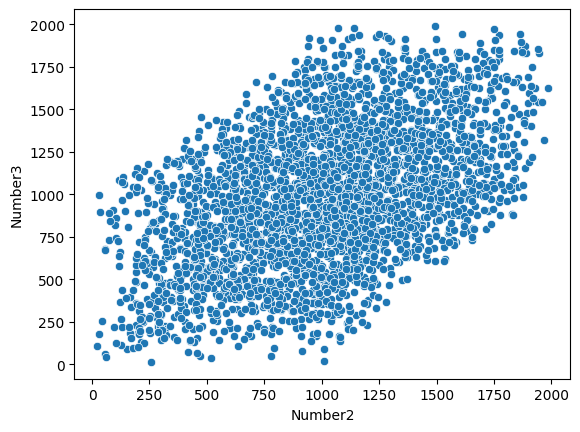

In [5]:
# Visualize data
sns.scatterplot(x=dataset["Number2"], y=dataset["Number3"], data=dataset)
plt.show()

In [6]:
# Select the required dependenta and independent data
x = dataset[["Number2"]]
y = dataset["Number3"]

In [7]:
# Train test split
from sklearn.model_selection import train_test_split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
# Build model
from sklearn.tree import DecisionTreeRegressor

In [10]:
dtr = DecisionTreeRegressor()
dtr.fit(x_train, y_train)

DecisionTreeRegressor()

In [11]:
# Check if the model is overfitted
dtr.score(x_train, y_train), dtr.score(x_test, y_test)
# Yes it is overfitted so we need to do hyperparameter tunning to make it more accurate

(1.0, -0.49597996003423983)

In [12]:
# Create a dictionary with the hyperparameters you want to tune
hyperparameters_to_tune = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "splitter": ["best", "random"],
    "max_depth": [i for i in range(2, 20)],
}

#### Using GridSearchCV

In [13]:
from sklearn.model_selection import GridSearchCV

In [14]:
gdcv= GridSearchCV(DecisionTreeRegressor(), param_grid=hyperparameters_to_tune)
gdcv.fit(x_train, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                       14, 15, 16, 17, 18, 19],
                         'splitter': ['best', 'random']})

In [15]:
# Check best score
gdcv.best_score_

np.float64(0.22709593448761511)

In [16]:
# Check the best hyperparameters value
gdcv.best_params_

{'criterion': 'absolute_error', 'max_depth': 3, 'splitter': 'best'}

In [17]:
# Train the model using best values of hyperparameters
dtr = DecisionTreeRegressor(criterion="friedman_mse", max_depth=5, splitter="random")
dtr.fit(x_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=5, splitter='random')

In [18]:
# Check if the model is overfitted
dtr.score(x_train, y_train), dtr.score(x_test, y_test)
# No it is not overfitted

(0.24453792071202674, 0.20853076751506505)

#### Using RandomizedSearchCV

In [19]:
from sklearn.model_selection import RandomizedSearchCV

In [20]:
rdcv = RandomizedSearchCV(DecisionTreeRegressor(), param_distributions=hyperparameters_to_tune, n_iter=20)
rdcv.fit(x_train, y_train)

RandomizedSearchCV(estimator=DecisionTreeRegressor(), n_iter=20,
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error',
                                                      'poisson'],
                                        'max_depth': [2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19],
                                        'splitter': ['best', 'random']})

In [21]:
# Check best score
rdcv.best_score_

np.float64(0.23107081162485638)

In [22]:
# Check the best hyperparameters value
rdcv.best_params_

{'splitter': 'random', 'max_depth': 5, 'criterion': 'poisson'}

In [23]:
# Train the model using best values of hyperparameters
dtr = DecisionTreeRegressor(criterion="friedman_mse", max_depth=5, splitter="random")
dtr.fit(x_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=5, splitter='random')

In [24]:
# Check if the model is overfitted
dtr.score(x_train, y_train), dtr.score(x_test, y_test)
# No it is not overfitted

(0.24116200504451524, 0.19605663593367129)